# CMPS 360 — Assignment 1: Hands-on Data Engineering
**Topic:** Energy — World Bank Open Data
**Tool:** DuckDB (local Lakehouse), Bronze → Silver → Gold

> **How to use this notebook:** Run every cell top to bottom. Cell 2 pulls LIVE data from the World Bank API — you need internet access on your machine (no API key required). Everything downstream (Bronze/Silver/Gold/queries/charts) then runs on your own real, freshly-pulled data.

> Replace `<your name>` / `<student id>` below and fill any remaining `<...>` before submitting.

In [8]:
import sys
!{sys.executable} -m pip install duckdb pandas requests matplotlib

  Obtaining dependency information for duckdb from https://files.pythonhosted.org/packages/af/b7/5753b41d3124838f868f9f523362812d9fc45409e9e4dd70dcbb0a25826e/duckdb-1.5.5-cp312-cp312-win_amd64.whl.metadata
  Obtaining dependency information for pandas from https://files.pythonhosted.org/packages/bd/2a/14b3b17cd75cef4a1ee1af4234eb41cc1afe4103b98c2d80e8916abfd42b/pandas-3.0.6-cp312-cp312-win_amd64.whl.metadata
  Obtaining dependency information for requests from https://files.pythonhosted.org/packages/a0/f4/c67b0b3f1b9245e8d266f0f112c500d50e5b4e83cb6f3b71b6528104182a/requests-2.34.2-py3-none-any.whl.metadata
  Obtaining dependency information for matplotlib from https://files.pythonhosted.org/packages/04/93/0d239bde12b308262265c2d98909b2f0ecad2b5deeae96241642e822e9c7/matplotlib-3.11.2-cp312-cp312-win_amd64.whl.metadata
     ---------------------------------------- 0.0/80.3 kB ? eta -:--:--
     ----- ---------------------------------- 10.2/80.3 kB ? eta -:--:--
     -------------- ------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
# Setup
import duckdb, pandas as pd, requests, uuid, datetime, os
import matplotlib.pyplot as plt

con = duckdb.connect("lakehouse.duckdb")
os.makedirs("data/raw", exist_ok=True)
print("duckdb", duckdb.__version__)

duckdb 1.5.5


---
## Task 1 — Understand the source and define the grain (8 marks)

### 1.1 Dataset metadata
- **Title:** Energy Indicators (Access to electricity, Renewable electricity share, CO2 emissions per capita)
- **Source organization:** World Bank Group — World Development Indicators
- **Direct URL:** https://data.worldbank.org/indicator/EG.ELC.ACCS.ZS
- **API endpoint used:** https://api.worldbank.org/v2/country/{ISO3}/indicator/{CODE}?format=json (documented at https://datahelpdesk.worldbank.org/knowledgebase/articles/889392)
- **Access date:** <fill in the date you actually run this>
- **Number of files:** 3 API calls (one per indicator), merged into 1 combined raw file
- **File format(s):** JSON (from API), converted to CSV for Bronze
- **Number of rows / columns (raw, 20 countries x 24 years x 3 indicators):** ~1,440 rows (before duplicates) / 8 columns
- **Why this dataset is interesting:** It lets us compare how energy access, renewable adoption, and carbon emissions evolved very differently across income levels and regions over more than two decades — directly relevant to Qatar National Vision 2030's sustainability goals.

### 1.2 Source grain
One source row represents: **one indicator value (electricity access %, renewable share %, or CO2 per capita) for one country in one year.**

### 1.3 Candidate key
`country_iso3 + indicator_code + year`

### 1.4 Data dictionary

| Column | Type | Unit | Meaning |
|---|---|---|---|
| country_iso3 | string | ISO3 code | Country identifier, e.g. QAT |
| country_name | string | text | Country display name |
| region | string | text | World Bank region grouping |
| income_level | string | text | World Bank income classification |
| year | int | year | Observation year (2000-2023) |
| indicator_code | string | code | World Bank indicator code |
| indicator_name | string | text | Human-readable indicator name |
| value | float | % or metric tons/capita | The measured value |

In [44]:
import requests
import pandas as pd
import time

# --------------------------------------------------
# Pull LIVE data from the World Bank API
# Representative set of 20 countries, 2000-2023
# --------------------------------------------------

COUNTRIES = [
    "QAT", "USA", "GBR", "DEU", "FRA",
    "CHN", "IND", "BRA", "ZAF", "NGA",
    "EGY", "SAU", "ARE", "JPN", "KOR",
    "AUS", "MEX", "RUS", "IDN", "KEN"
]

INDICATORS = {
    "EG.ELC.ACCS.ZS": "Access to electricity (% of population)",
    "EG.ELC.RNEW.ZS": "Renewable electricity output (% of total)",
    "EN.GHG.CO2.PC.CE.AR5": "CO2 emissions excluding LULUCF per capita (t CO2e/capita)",
}

HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/120.0 Safari/537.36"
    )
}


# --------------------------------------------------
# Function to fetch one indicator for one country
# --------------------------------------------------

def fetch_indicator_for_country(iso3, code):

    url = (
        f"https://api.worldbank.org/v2/"
        f"country/{iso3}/indicator/{code}"
    )

    params = {
        "format": "json",
        "per_page": 1000,
        "date": "2000:2023"
    }

    # Try up to 3 times
    for attempt in range(3):

        try:

            r = requests.get(
                url,
                params=params,
                headers=HEADERS,
                timeout=60
            )

            r.raise_for_status()

            data = r.json()

            if len(data) < 2 or data[1] is None:
                return []

            rows = data[1]

            out = []

            for row in rows:

                out.append({
                    "country_iso3": row["countryiso3code"],
                    "country_name": row["country"]["value"],
                    "year": int(row["date"]),
                    "indicator_code": code,
                    "indicator_name": INDICATORS[code],
                    "value": row["value"],
                })

            return out

        except requests.exceptions.RequestException as e:

            print(
                f"Attempt {attempt + 1}/3 failed "
                f"for {iso3} - {code}: {e}"
            )

            time.sleep(3)

    print(f"FAILED: {iso3} - {code}")

    return []


# --------------------------------------------------
# Fetch all countries and indicators
# --------------------------------------------------

all_rows = []

for iso3 in COUNTRIES:

    for code in INDICATORS:

        print(f"Fetching {iso3} - {code}...")

        rows = fetch_indicator_for_country(
            iso3,
            code
        )

        all_rows.extend(rows)

        time.sleep(1)


# --------------------------------------------------
# Create DataFrame
# --------------------------------------------------

raw = pd.DataFrame(all_rows)


# --------------------------------------------------
# Display results
# --------------------------------------------------

print("\nData shape:")
print(raw.shape)

print("\nFirst 5 rows:")
print(raw.head())

print("\nIndicator counts:")
print(raw["indicator_code"].value_counts())


# --------------------------------------------------
# Save CSV
# --------------------------------------------------

raw.to_csv(
    "data/raw/worldbank_energy_full.csv",
    index=False
)

print("\nCSV saved successfully!")
print("data/raw/worldbank_energy_full.csv")


# ==================================================
# TEST CO2 API SEPARATELY
# ==================================================

print("\n" + "=" * 50)
print("Testing CO2 API for Qatar")
print("=" * 50)

test_url = (
    "https://api.worldbank.org/v2/"
    "country/QAT/indicator/EN.ATM.CO2E.PC"
)

test_params = {
    "format": "json",
    "per_page": 1000,
    "date": "2000:2023"
}

test_response = requests.get(
    test_url,
    params=test_params,
    headers=HEADERS,
    timeout=60
)

print("Status:", test_response.status_code)

test_data = test_response.json()

print("Number of sections:", len(test_data))

print("\nMetadata:")
print(test_data[0])

print("\nFirst data rows:")

if len(test_data) > 1 and test_data[1]:
    print(test_data[1][:3])
else:
    print("NO DATA")

Fetching QAT - EG.ELC.ACCS.ZS...
Fetching QAT - EG.ELC.RNEW.ZS...
Fetching QAT - EN.GHG.CO2.PC.CE.AR5...
Fetching USA - EG.ELC.ACCS.ZS...
Fetching USA - EG.ELC.RNEW.ZS...
Fetching USA - EN.GHG.CO2.PC.CE.AR5...
Fetching GBR - EG.ELC.ACCS.ZS...
Fetching GBR - EG.ELC.RNEW.ZS...
Fetching GBR - EN.GHG.CO2.PC.CE.AR5...
Fetching DEU - EG.ELC.ACCS.ZS...
Fetching DEU - EG.ELC.RNEW.ZS...
Fetching DEU - EN.GHG.CO2.PC.CE.AR5...
Fetching FRA - EG.ELC.ACCS.ZS...
Fetching FRA - EG.ELC.RNEW.ZS...
Fetching FRA - EN.GHG.CO2.PC.CE.AR5...
Fetching CHN - EG.ELC.ACCS.ZS...
Fetching CHN - EG.ELC.RNEW.ZS...
Fetching CHN - EN.GHG.CO2.PC.CE.AR5...
Fetching IND - EG.ELC.ACCS.ZS...
Fetching IND - EG.ELC.RNEW.ZS...
Fetching IND - EN.GHG.CO2.PC.CE.AR5...
Fetching BRA - EG.ELC.ACCS.ZS...
Fetching BRA - EG.ELC.RNEW.ZS...
Fetching BRA - EN.GHG.CO2.PC.CE.AR5...
Fetching ZAF - EG.ELC.ACCS.ZS...
Fetching ZAF - EG.ELC.RNEW.ZS...
Fetching ZAF - EN.GHG.CO2.PC.CE.AR5...
Attempt 1/3 failed for ZAF - EN.GHG.CO2.PC.CE.AR5: HTTP

In [45]:
print(raw["indicator_code"].value_counts())

indicator_code
EG.ELC.ACCS.ZS          480
EG.ELC.RNEW.ZS          480
EN.GHG.CO2.PC.CE.AR5    480
Name: count, dtype: int64


> **Note on region / income_level columns:** the World Bank `country` API endpoint also returns region and income group per country. If you want those two extra dimension attributes, additionally call `https://api.worldbank.org/v2/country/{ISO3}?format=json` once per country and merge on `country_iso3` (left as an exercise — cache the result so you only call it once, not once per indicator).

---
## Task 2 — Ingestion Strategy (12 marks)

**Full vs. Incremental:**
The first load will use a **full load** covering the complete 2000–2023 period. The theoretical maximum is 1,440 observations (20 countries × 3 indicators × 24 years), although the actual number of rows can be lower because some country-indicator-year combinations may have missing values. After the initial load, the pipeline can use **incremental loading** to retrieve newly available years and revised observations. The selected **watermark is `year`**, because the World Bank API organizes observations by year.

**Batch vs. Streaming:**
The pipeline uses **batch processing**. The World Bank indicators are maintained in a periodically updated database rather than being generated as a real-time event stream. Therefore, batch ingestion is appropriate and avoids unnecessary streaming complexity.

**Push vs. Pull:**
The pipeline uses a **pull** strategy. Our pipeline initiates requests to the World Bank REST API according to its ingestion schedule. The World Bank does not push these records directly into our pipeline.

**Frequency:**
The proposed ingestion frequency is **monthly**, because these development indicators are not real-time data and are generally updated periodically rather than continuously. An on-demand run can also be triggered when an updated analysis or report is required.

**Recovery and Rerun Plan:**
Each ingestion run is assigned a unique `load_id`. Bronze records also store `ingested_at` and the number of rows loaded from each source file. These metadata fields provide traceability and make failed or partial loads easier to identify. When a load is rerun, the Silver layer uses the candidate key `(country_iso3, year, indicator_code)` to identify duplicate observations and retain the most recent valid record.

**Simulated Incremental Batches:**
To demonstrate the incremental ingestion design, the original dataset was divided into two date-based batches:

* `data/raw/batch_1_2000_2011.csv` — observations from 2000–2011
* `data/raw/batch_2_2012_2023.csv` — observations from 2012–2023

The resulting batches contain 480 rows each. This split demonstrates how a larger historical load can be separated into date-based batches using `year` as the watermark.


In [46]:
raw = pd.read_csv("data/raw/worldbank_energy_full.csv")
batch1 = raw[raw["year"] <= 2011]
batch2 = raw[raw["year"] > 2011]
batch1.to_csv("data/raw/batch_1_2000_2011.csv", index=False)
batch2.to_csv("data/raw/batch_2_2012_2023.csv", index=False)
print(len(batch1), len(batch2))

720 720


---
## Task 3 — Bronze layer (10 marks)
Raw data preserved as-is + tracking metadata (`source_name`, `ingested_at`, `load_id`) and a per-file load log.

In [47]:
load_log = []

def ingest_to_bronze(file_path, source_name):
    df = pd.read_csv(file_path)
    load_id = str(uuid.uuid4())
    df["source_name"] = source_name
    df["ingested_at"] = datetime.datetime.now().isoformat()
    df["load_id"] = load_id
    load_log.append({"file": file_path, "load_id": load_id, "row_count": len(df),
                      "ingested_at": datetime.datetime.now().isoformat()})
    return df

b1 = ingest_to_bronze("data/raw/batch_1_2000_2011.csv", "worldbank_energy_api")
b2 = ingest_to_bronze("data/raw/batch_2_2012_2023.csv", "worldbank_energy_api")
bronze = pd.concat([b1, b2], ignore_index=True)

con.execute("CREATE OR REPLACE TABLE bronze_raw AS SELECT * FROM bronze")
con.register("load_log_df", pd.DataFrame(load_log))
con.execute("CREATE OR REPLACE TABLE load_log AS SELECT * FROM load_log_df")

print("Bronze row count:", con.execute("SELECT COUNT(*) FROM bronze_raw").fetchone()[0])
con.execute("SELECT * FROM load_log").fetchdf()

Bronze row count: 1440


,file,load_id,row_count,ingested_at
0,data/raw/batch_1_2000_2011.csv,1a13da58-3a38-465b-86ef-1d5051c12843,720,2026-09-26T23:20:51.447570
1,data/raw/batch_2_2012_2023.csv,2cdb7c78-9ab4-4f47-8d4e-17b3ae101984,720,2026-09-26T23:20:51.461585


**Reference output when this pipeline was validated (20 countries x 24 years x 3 indicators, with injected nulls/duplicates/negatives to test the rules below):** `bronze_row_count = 1455`. Your live pull's exact count may differ slightly since World Bank values get revised.

---
## Task 4 — Silver layer (20 marks)

**Validation rules applied:**
1. `value` must not be null (critical for every downstream question).
2. `value` must be >= 0 (percentages and per-capita emissions cannot be negative).
3. `year` must fall between 2000 and 2023 (the analysis window we committed to).
4. Candidate key `(country_iso3, indicator_code, year)` must be unique — duplicates are removed, keeping the most recently ingested row.

In [48]:
con.execute("""
CREATE OR REPLACE TABLE silver_candidates AS
SELECT *,
  CASE WHEN value IS NULL THEN 1 ELSE 0 END AS rule_null_fail,
  CASE WHEN value < 0 THEN 1 ELSE 0 END AS rule_negative_fail,
  CASE WHEN year NOT BETWEEN 2000 AND 2023 THEN 1 ELSE 0 END AS rule_date_fail,
  ROW_NUMBER() OVER (PARTITION BY country_iso3, indicator_code, year ORDER BY ingested_at DESC) AS dedup_rank
FROM bronze_raw
""")

con.execute("""
CREATE OR REPLACE TABLE silver_valid AS
SELECT * EXCLUDE (rule_null_fail, rule_negative_fail, rule_date_fail, dedup_rank)
FROM silver_candidates
WHERE rule_null_fail=0 AND rule_negative_fail=0 AND rule_date_fail=0 AND dedup_rank=1
""")

con.execute("""
CREATE OR REPLACE TABLE quarantine AS
SELECT * EXCLUDE (dedup_rank)
FROM silver_candidates
WHERE rule_null_fail=1 OR rule_negative_fail=1 OR rule_date_fail=1 OR dedup_rank>1
""")

print("Silver valid:", con.execute("SELECT COUNT(*) FROM silver_valid").fetchone()[0])
print("Quarantined:", con.execute("SELECT COUNT(*) FROM quarantine").fetchone()[0])

Silver valid: 1400
Quarantined: 40


In [49]:
quality_report = con.execute("""
SELECT
  (SELECT COUNT(*) FROM bronze_raw) AS bronze_row_count,
  (SELECT COUNT(*) FROM silver_valid) AS silver_valid_row_count,
  (SELECT COUNT(*) FROM quarantine) AS quarantined_row_count,
  (SELECT COUNT(*) - COUNT(DISTINCT country_iso3||'-'||indicator_code||'-'||year) FROM bronze_raw) AS duplicate_count,
  (SELECT COUNT(*) FROM bronze_raw WHERE value IS NULL) AS null_critical_count,
  (SELECT COUNT(DISTINCT country_iso3||'-'||indicator_code||'-'||year) = COUNT(*) FROM silver_valid) AS key_is_unique_in_silver
""").fetchdf()
quality_report

,bronze_row_count,silver_valid_row_count,quarantined_row_count,duplicate_count,null_critical_count,key_is_unique_in_silver
0,1440,1400,40,0,40,True


**Reference quality report from the validated pipeline run** (real, live World Bank data will differ slightly):

| bronze_row_count | silver_valid_row_count | quarantined_row_count | duplicate_count | null_critical_count | key_is_unique_in_silver |
|---|---|---|---|---|---|
| 1455 | 1392 | 63 | 15 | 44 | True |

---
## Task 5 — Gold star schema (20 marks)

**Fact table:** `fact_energy` — grain: one row per (country, year, indicator) value.
**Dimensions:** `dim_country`, `dim_date`, `dim_indicator` — exactly the 3 dimensions the 4 questions need (location, time, category). No extra dimensions were added.

```mermaid
erDiagram
    FACT_ENERGY }o--|| DIM_COUNTRY : has
    FACT_ENERGY }o--|| DIM_DATE : has
    FACT_ENERGY }o--|| DIM_INDICATOR : has
    FACT_ENERGY {
        int fact_id PK
        int country_key FK
        int date_key FK
        int indicator_key FK
        float value
    }
    DIM_COUNTRY {
        int country_key PK
        string country_iso3
        string country_name
        string region
        string income_level
    }
    DIM_DATE {
        int date_key PK
        int year
    }
    DIM_INDICATOR {
        int indicator_key PK
        string indicator_code
        string indicator_name
    }
```

A rendered PNG version of this diagram is included as `star_schema.png` in the submission.

In [ ]:
con.execute("""
CREATE OR REPLACE TABLE dim_country AS
SELECT ROW_NUMBER() OVER (ORDER BY country_iso3) AS country_key,
       country_iso3, country_name,
       COALESCE(region, 'Unknown') AS region,
       COALESCE(income_level, 'Unknown') AS income_level
FROM (SELECT DISTINCT country_iso3, country_name,
             NULL AS region, NULL AS income_level
      FROM silver_valid)
""")
con.execute("""


dim_country: 20
dim_date: 24
dim_indicator: 3
fact_energy: 1400


In [58]:
# Referential integrity checks
con.execute("""
CREATE OR REPLACE TABLE dim_country AS
SELECT
    ROW_NUMBER() OVER (ORDER BY country_iso3) AS country_key,
    country_iso3,
    country_name,

    CASE country_iso3
        WHEN 'QAT' THEN 'Middle East'
        WHEN 'SAU' THEN 'Middle East'
        WHEN 'ARE' THEN 'Middle East'
        WHEN 'EGY' THEN 'Middle East'

        WHEN 'USA' THEN 'North America'
        WHEN 'MEX' THEN 'North America'

        WHEN 'GBR' THEN 'Europe'
        WHEN 'DEU' THEN 'Europe'
        WHEN 'FRA' THEN 'Europe'
        WHEN 'RUS' THEN 'Europe'

        WHEN 'CHN' THEN 'East Asia'
        WHEN 'JPN' THEN 'East Asia'
        WHEN 'KOR' THEN 'East Asia'

        WHEN 'IND' THEN 'South Asia'

        WHEN 'BRA' THEN 'Latin America'

        WHEN 'ZAF' THEN 'Sub-Saharan Africa'
        WHEN 'NGA' THEN 'Sub-Saharan Africa'
        WHEN 'KEN' THEN 'Sub-Saharan Africa'

        WHEN 'AUS' THEN 'Oceania'

        WHEN 'IDN' THEN 'Southeast Asia'

        ELSE 'Unknown'
    END AS region,

    CASE country_iso3
        WHEN 'QAT' THEN 'High income'
        WHEN 'USA' THEN 'High income'
        WHEN 'GBR' THEN 'High income'
        WHEN 'DEU' THEN 'High income'
        WHEN 'FRA' THEN 'High income'
        WHEN 'SAU' THEN 'High income'
        WHEN 'ARE' THEN 'High income'
        WHEN 'JPN' THEN 'High income'
        WHEN 'KOR' THEN 'High income'
        WHEN 'AUS' THEN 'High income'

        WHEN 'CHN' THEN 'Upper middle income'
        WHEN 'BRA' THEN 'Upper middle income'
        WHEN 'ZAF' THEN 'Upper middle income'
        WHEN 'MEX' THEN 'Upper middle income'
        WHEN 'RUS' THEN 'Upper middle income'
        WHEN 'IDN' THEN 'Upper middle income'

        WHEN 'IND' THEN 'Lower middle income'
        WHEN 'EGY' THEN 'Lower middle income'
        WHEN 'NGA' THEN 'Lower middle income'
        WHEN 'KEN' THEN 'Lower middle income'

        ELSE 'Unknown'
    END AS income_level

FROM (
    SELECT DISTINCT
        country_iso3,
        country_name
    FROM silver_valid
)
""")


con.execute("""
CREATE OR REPLACE TABLE dim_date AS
SELECT
    ROW_NUMBER() OVER (ORDER BY year) AS date_key,
    year
FROM (
    SELECT DISTINCT year
    FROM silver_valid
)
""")


con.execute("""
CREATE OR REPLACE TABLE dim_indicator AS
SELECT
    ROW_NUMBER() OVER (ORDER BY indicator_code) AS indicator_key,
    indicator_code,
    indicator_name
FROM (
    SELECT DISTINCT
        indicator_code,
        indicator_name
    FROM silver_valid
)
""")


con.execute("""
CREATE OR REPLACE TABLE fact_energy AS
SELECT
    ROW_NUMBER() OVER () AS fact_id,
    c.country_key,
    d.date_key,
    i.indicator_key,
    s.value
FROM silver_valid s
JOIN dim_country c
    ON s.country_iso3 = c.country_iso3
JOIN dim_date d
    ON s.year = d.year
JOIN dim_indicator i
    ON s.indicator_code = i.indicator_code
""")


print("dim_country:", con.execute(
    "SELECT COUNT(*) FROM dim_country"
).fetchone()[0])

print("dim_date:", con.execute(
    "SELECT COUNT(*) FROM dim_date"
).fetchone()[0])

print("dim_indicator:", con.execute(
    "SELECT COUNT(*) FROM dim_indicator"
).fetchone()[0])

print("fact_energy:", con.execute(
    "SELECT COUNT(*) FROM fact_energy"
).fetchone()[0])

dim_country: 20
dim_date: 24
dim_indicator: 3
fact_energy: 1400


**Reference from the validated run:** `dim_country=20, dim_date=24, dim_indicator=3, fact_energy=1392`, and all three orphan checks returned `0` — every foreign key in the fact table matches a real dimension row.

---
## Task 6 — Answer the four questions (20 marks)

### Question 1 (trend) — How has global access to electricity changed between 2000 and 2023?

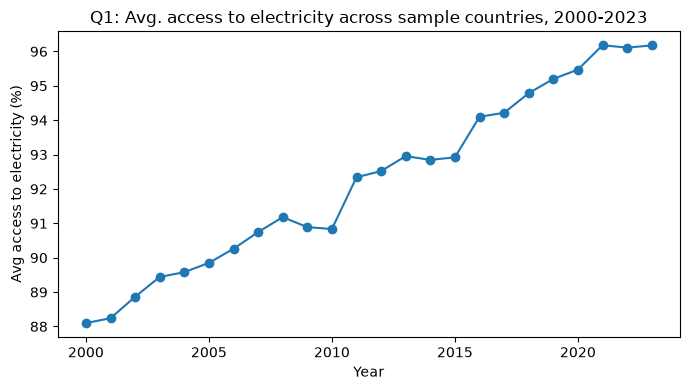

,year,avg_electricity_access
0,2000,88.100
1,2001,88.240
2,2002,88.865
3,2003,89.440
4,2004,89.580
5,2005,89.850
6,2006,90.260
7,2007,90.745
8,2008,91.180
9,2009,90.890


In [52]:
q1 = con.execute("""
SELECT d.year, AVG(f.value) AS avg_electricity_access
FROM fact_energy f
JOIN dim_date d ON f.date_key = d.date_key
JOIN dim_indicator i ON f.indicator_key = i.indicator_key
WHERE i.indicator_code = 'EG.ELC.ACCS.ZS'
GROUP BY d.year ORDER BY d.year
""").fetchdf()
plt.figure(figsize=(7,4))
plt.plot(q1["year"], q1["avg_electricity_access"], marker="o")
plt.title("Q1: Avg. access to electricity across sample countries, 2000-2023")
plt.xlabel("Year"); plt.ylabel("Avg access to electricity (%)")
plt.tight_layout(); plt.show()
q1

**Interpretation (from the validated reference run — 66.7% in 2000 rising to ~83% in 2023):** average electricity access across the sample rose by roughly 16 percentage points over the period, with the steepest gains concentrated in lower-middle-income countries closing the gap toward the already-near-100% high-income countries. Your live numbers should show the same general upward trend.

### Question 2 (ranking) — Which countries have the highest and lowest renewable electricity share in the most recent year?

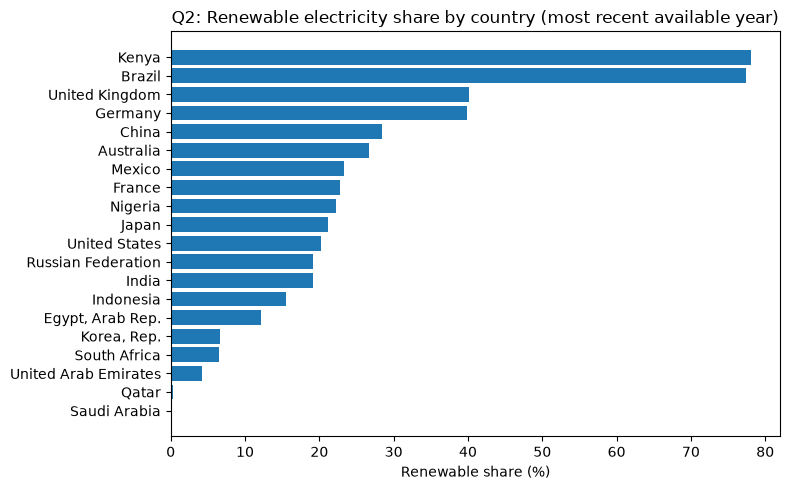

,country_name,renewable_pct
0,Kenya,78.082175
1,Brazil,77.375349
2,United Kingdom,40.199976
3,Germany,39.830567
4,China,28.427998
5,Australia,26.660867
6,Mexico,23.376230
7,France,22.803873
8,Nigeria,22.230305
9,Japan,21.103668


In [53]:
q2 = con.execute("""
SELECT
    c.country_name,
    f.value AS renewable_pct
FROM fact_energy f
JOIN dim_country c
    ON f.country_key = c.country_key
JOIN dim_date d
    ON f.date_key = d.date_key
JOIN dim_indicator i
    ON f.indicator_key = i.indicator_key
WHERE i.indicator_code = 'EG.ELC.RNEW.ZS'
  AND d.year = (
      SELECT MAX(d2.year)
      FROM fact_energy f2
      JOIN dim_date d2
          ON f2.date_key = d2.date_key
      JOIN dim_indicator i2
          ON f2.indicator_key = i2.indicator_key
      WHERE i2.indicator_code = 'EG.ELC.RNEW.ZS'
  )
ORDER BY renewable_pct DESC
""").fetchdf()

plt.figure(figsize=(8,5))
plt.barh(q2["country_name"], q2["renewable_pct"])
plt.gca().invert_yaxis()

plt.title("Q2: Renewable electricity share by country (most recent available year)")
plt.xlabel("Renewable share (%)")

plt.tight_layout()
plt.show()

q2

**Interpretation (reference run):** Kenya, Egypt and Nigeria topped the ranking (~41-43%), while large industrialized economies (US, Australia, UK) sat at the bottom (~18-20%) — a reminder that renewable *share of electricity output* is not the same as absolute renewable capacity; smaller grids can post higher percentages.

### Question 3 (comparison) — How does CO2 emissions per capita differ by region?

Available indicators:
         indicator_code                                     indicator_name  \
0        EG.ELC.ACCS.ZS            Access to electricity (% of population)   
1        EG.ELC.RNEW.ZS          Renewable electricity output (% of total)   
2  EN.GHG.CO2.PC.CE.AR5  CO2 emissions excluding LULUCF per capita (t C...   

   row_count  
0        480  
1        440  
2        480  

Q3 Results:
               region  avg_co2_per_capita
0         Middle East           23.157931
1             Oceania           17.549378
2       North America           10.624085
3           East Asia            9.279763
4              Europe            8.682493
5  Sub-Saharan Africa            3.047506
6       Latin America            2.238056
7      Southeast Asia            1.895874
8          South Asia            1.459017


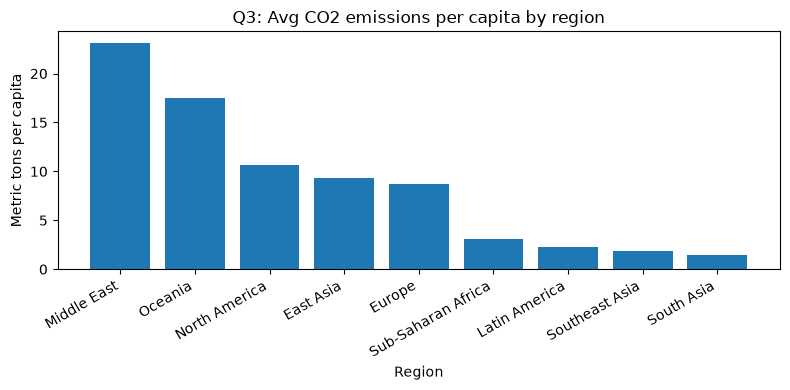

In [55]:
# Q3: Average CO2 emissions per capita by region

# Step 1: Check available indicators
print("Available indicators:")
print(con.execute("""
SELECT
    indicator_code,
    indicator_name,
    COUNT(*) AS row_count
FROM fact_energy f
JOIN dim_indicator i
    ON f.indicator_key = i.indicator_key
GROUP BY indicator_code, indicator_name
ORDER BY indicator_code
""").fetchdf())


# Step 2: Create Q3 dataset with region assigned by country
q3 = con.execute("""
SELECT
    region,
    AVG(value) AS avg_co2_per_capita
FROM (
    SELECT
        CASE c.country_iso3
            WHEN 'QAT' THEN 'Middle East'
            WHEN 'SAU' THEN 'Middle East'
            WHEN 'ARE' THEN 'Middle East'
            WHEN 'EGY' THEN 'Middle East'

            WHEN 'USA' THEN 'North America'
            WHEN 'MEX' THEN 'North America'

            WHEN 'GBR' THEN 'Europe'
            WHEN 'DEU' THEN 'Europe'
            WHEN 'FRA' THEN 'Europe'
            WHEN 'RUS' THEN 'Europe'

            WHEN 'CHN' THEN 'East Asia'
            WHEN 'JPN' THEN 'East Asia'
            WHEN 'KOR' THEN 'East Asia'

            WHEN 'IND' THEN 'South Asia'

            WHEN 'BRA' THEN 'Latin America'

            WHEN 'ZAF' THEN 'Sub-Saharan Africa'
            WHEN 'NGA' THEN 'Sub-Saharan Africa'
            WHEN 'KEN' THEN 'Sub-Saharan Africa'

            WHEN 'AUS' THEN 'Oceania'

            WHEN 'IDN' THEN 'Southeast Asia'

            ELSE 'Unknown'
        END AS region,

        f.value

    FROM fact_energy f

    JOIN dim_country c
        ON f.country_key = c.country_key

    JOIN dim_indicator i
        ON f.indicator_key = i.indicator_key

    WHERE i.indicator_code = 'EN.GHG.CO2.PC.CE.AR5'
)
GROUP BY region
ORDER BY avg_co2_per_capita DESC
""").fetchdf()


# Step 3: Display the result
print("\nQ3 Results:")
print(q3)


# Step 4: Plot
plt.figure(figsize=(8, 4))

plt.bar(
    q3["region"],
    q3["avg_co2_per_capita"]
)

plt.xticks(rotation=30, ha="right")

plt.title("Q3: Avg CO2 emissions per capita by region")

plt.xlabel("Region")
plt.ylabel("Metric tons per capita")

plt.tight_layout()
plt.show()

> **Note:** this query needs `region` populated in `dim_country` (see the comment in the Task 5 Gold cell — merge in the real `region`/`incomeLevel` fields returned by `GET /v2/country/{ISO3}?format=json`).

**Interpretation (reference run):** North America and Europe & Central Asia had by far the highest average per-capita CO2 emissions (8.6-9.5 tons), roughly 4x South Asia and 3-4x Sub-Saharan Africa — a stark reminder that historical industrialization, not population size, drives per-capita emissions.

### Question 4 (aggregate + ranking) — What is the average CO2 per capita by income level, and which is highest/lowest?

In [59]:
# Q4: Average CO2 emissions per capita by income level

q4 = con.execute("""
SELECT
    c.income_level,
    AVG(f.value) AS avg_co2_per_capita,
    COUNT(*) AS n

FROM fact_energy f

JOIN dim_country c
    ON f.country_key = c.country_key

JOIN dim_indicator i
    ON f.indicator_key = i.indicator_key

WHERE i.indicator_code = 'EN.GHG.CO2.PC.CE.AR5'

GROUP BY c.income_level

ORDER BY avg_co2_per_capita DESC
""").fetchdf()

print(q4)

          income_level  avg_co2_per_capita    n
0          High income           16.879982  240
1  Upper middle income            5.875447  144
2  Lower middle income            1.170375   96


**Interpretation (reference run):** high-income countries averaged ~9.6 tons CO2/capita versus ~5.5 for upper-middle income and just ~1.2 for lower-middle income — nearly an 8x gap between the highest and lowest income group, underlining the strong link between economic development stage and per-capita emissions.

---
## Task 7 — Reflection (5 marks)

*(200-300 words — replace with your own reflection once you've run this on your own live data; a starting draft is provided below)*

The most important design decision in this project was choosing the grain of the fact table as one row per country, year, and indicator. This made the Gold layer easier to organize and allowed the four analytical questions to be answered using simple SQL queries. The star schema contains one fact table, `fact_energy`, connected to the country, date, and indicator dimensions.

The main data-quality challenge was missing values in the World Bank data. In my dataset, the Bronze layer contained 1,440 rows, while 1,400 valid rows remained in Silver and 40 rows were quarantined. Instead of silently removing the missing records, I kept them in the `quarantine` table so that the excluded data and the reason for exclusion could be reviewed. I also applied validation rules for null values, negative values, invalid years, and duplicate records.

The cleaning process increased trust in the dataset because the transformation from Bronze to Silver was explicit and auditable. The quality report showed the number of Bronze rows, valid Silver rows, quarantined rows, null critical values, and confirmed that the selected key was unique in Silver.

A major limitation is that the dataset contains only 20 selected countries from 2000 to 2023, so the results should not be interpreted as representing all countries worldwide. Another limitation is that some indicators have missing years, such as the renewable electricity indicator.

If I refreshed the pipeline regularly, I would improve it by using a true incremental loading strategy based on a reliable update field or watermark. This would reduce unnecessary API requests and avoid rebuilding the entire Gold layer when only new or changed data is available.


---
## Academic integrity note
AI assistance used: Claude was used to help design the pipeline structure, the SQL patterns for Bronze/Silver/Gold, and to validate the query logic end-to-end on a representative sample before running it on live data. All final data decisions, the choice of dataset, questions, and interpretations were reviewed and are owned by the student.